# Modelado Predictivo de Churn — Telecomunicaciones

> **Prueba técnica SDG Group — Data Scientist**

---

## Objetivo

Construir un modelo predictivo de churn que:

1. **Prediga** qué clientes abandonarán la empresa en los próximos 31-60 días.
2. **Explique** qué factores impulsan el churn (feature importance + SHAP).
3. **Genere recomendaciones accionables** para el equipo de retención.
4. **Se serialice como pickle** para integrarse en el DAG de Airflow.

## Estrategia de modelado

Tras el benchmark inicial de 6 modelos con cross-validation, la evidencia empírica mostró:

| Modelo | AUC-ROC | F1 | Razón de inclusión |
|---|---|---|---|
| Logistic Regression | 0.626 | 0.584 | **Baseline interpretable** — referencia para cuantificar el valor añadido de modelos complejos |
| XGBoost | 0.694 | 0.638 | **Modelo principal** — mejor balance rendimiento/interpretabilidad/compatibilidad |
| LightGBM | 0.694 | 0.640 | **Modelo de comparación** — valida que la elección no es arbitraria |

### ¿Por qué estos tres y no otros?

**Logistic Regression como baseline:**
- En cualquier proyecto serio de ML, el primer modelo debe ser simple. Si un XGBoost solo gana 1 punto sobre una regresión logística, el coste de complejidad no se justifica.
- En nuestro caso, el gap es de **+7 puntos de AUC** (0.626 → 0.694), lo que confirma que las interacciones no lineales entre variables son fundamentales para predecir churn.
- Además, los coeficientes de la logística nos dan una primera capa de interpretabilidad lineal.

**XGBoost como modelo principal:**
- Gradient boosting es el estándar de la industria para datos tabulares estructurados (papers de referencia: Chen & Guestrin 2016).
- Maneja valores faltantes de forma nativa (no necesita imputación perfecta).
- Tiene regularización incorporada (L1, L2, max_depth, min_child_weight) que previene overfitting.
- Compatible con SHAP de forma nativa y eficiente (TreeExplainer).
- Serializa limpiamente a pickle para el pipeline de Airflow.

**LightGBM como comparación:**
- Empata con XGBoost en rendimiento pero entrena más rápido (histogram-based splitting).
- Si en producción el reentrenamiento frecuente es prioritario, LightGBM sería preferible.
- Tenerlo permite demostrar en la presentación que se evaluaron alternativas.

### ¿Por qué NO otros modelos?

- **Decision Tree:** AUC 0.638 — peor que RF y boosting. Overfittea fácilmente.
- **Random Forest:** AUC 0.671 — decente pero 2.3 puntos por debajo de boosting y 5× más lento.
- **SVM:** No escala bien a 100K filas × 88 features. Tiempos de entrenamiento prohibitivos.
- **Redes neuronales (MLP, TabNet):** Para datasets tabulares de este tamaño, boosting las supera consistentemente (Grinsztajn et al., 2022). Además, son difíciles de interpretar con SHAP.

---

## Índice

1. [Setup y carga de datos](#s1)
2. [Preprocesamiento para modelado](#s2)
3. [Split estratificado train/val/test](#s3)
4. [Modelo 1: Logistic Regression (Baseline)](#s4)
5. [Modelo 2: XGBoost (Principal)](#s5)
6. [Modelo 3: LightGBM (Comparación)](#s6)
7. [Comparación de modelos](#s7)
8. [Hyperparameter tuning del modelo ganador](#s8)
9. [Evaluación final sobre test set](#s9)
10. [Interpretabilidad — SHAP](#s10)
11. [Curva de Lift — valor para negocio](#s11)
12. [Ablation study: ¿change_mou es leakage?](#s12)
13. [Conclusiones de negocio y recomendaciones](#s13)
14. [Guardado del modelo (pickle) para Airflow](#s14)


---
<a id="s1"></a>
## 1. Setup y carga de datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, f1_score, recall_score, precision_score,
                             accuracy_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carga del dataset limpio generado por 02_EDA_Profundo
df = pd.read_csv('dataset_clean.csv', sep=';', decimal=',', low_memory=False)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Churn rate: {df['churn'].mean():.4f} (recordatorio: balanceado artificialmente)")
print(f"Columnas: {list(df.columns)}")

Dataset cargado: 100,000 filas x 88 columnas
Churn rate: 0.4956 (recordatorio: balanceado artificialmente)
Columnas: ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'complete_Mean', 'callwait_Mean', 'churn', 'months', 'uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualban

---
<a id="s2"></a>
## 2. Preprocesamiento para modelado

### Decisiones de diseño

1. **Variables categóricas → Label Encoding** para los modelos de árboles (XGBoost, LightGBM). Los árboles no necesitan one-hot encoding porque hacen splits binarios. Label encoding preserva la memoria y velocidad. Para Logistic Regression usaremos los mismos labels + escalado (no ideal, pero al ser baseline es aceptable; la alternativa sería one-hot que con `crclscod` genera 40+ columnas sparse).

2. **Valores nulos numéricos → Imputación con mediana.** La mediana es robusta a outliers (que tenemos muchos según el EDA). Los modelos de boosting pueden manejar NaN nativamente, pero imputamos para mantener consistencia entre modelos.

3. **Escalado → Solo para Logistic Regression.** Los árboles son invariantes a escala.

4. **No hacemos oversampling/undersampling** porque el dataset ya está balanceado 50/50.


In [2]:
# Separar target y features
y = df['churn'].values
X = df.drop(columns=['churn']).copy()

# Identificar tipos
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Features totales: {X.shape[1]}")
print(f"  Numéricas:   {len(num_cols)}")
print(f"  Categóricas: {len(cat_cols)} -> {cat_cols}")

# === Label encoding para categóricas ===
label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    # Tratamos NaN como categoría 'MISSING'
    X[c] = X[c].fillna('MISSING')
    X[c] = le.fit_transform(X[c])
    label_encoders[c] = le
    print(f"  {c:20s} -> {len(le.classes_)} categorías: {list(le.classes_[:5])}{'...' if len(le.classes_)>5 else ''}")

# === Imputación de nulos numéricos con mediana ===
null_before = X[num_cols].isnull().sum().sum()
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])
null_after = X[num_cols].isnull().sum().sum()
print(f"\nNulos numéricos imputados: {null_before:,} -> {null_after}")

# Verificación final
assert X.isnull().sum().sum() == 0, "Aún quedan nulos!"
print(f"\n✅ Dataset preprocesado: {X.shape} — sin nulos")

# Guardar nombres de features para SHAP
feature_names = X.columns.tolist()

Features totales: 87
  Numéricas:   71
  Categóricas: 16 -> ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'creditcd']
  new_cell             -> 3 categorías: ['MISSING', 'N', 'Y']
  crclscod             -> 53 categorías: ['A', 'A2', 'A3', 'AA', 'B']...
  asl_flag             -> 2 categorías: ['N', 'Y']
  prizm_social_one     -> 5 categorías: ['C', 'MISSING', 'R', 'S', 'T']
  area                 -> 20 categorías: ['ATLANTIC SOUTH AREA', 'CALIFORNIA NORTH AREA', 'CENTRAL/SOUTH TEXAS AREA', 'CHICAGO AREA', 'DALLAS AREA']...
  dualband             -> 4 categorías: ['MISSING', 'N', 'T', 'Y']
  refurb_new           -> 3 categorías: ['MISSING', 'N', 'R']
  hnd_webcap           -> 4 categorías: ['MISSING', 'UNKW', 'WC', 'WCMB']
  ownrent              -> 3 categorías: ['MISSING', 'O', 'R']
  dwlltype             -> 3 categorías: ['M', 'MISSING', 'S']
  mari

  ethnic               -> 16 categorías: ['B', 'C', 'D', 'F', 'G']...
  creditcd             -> 3 categorías: ['MISSING', 'N', 'Y']



Nulos numéricos imputados: 144,952 -> 0

✅ Dataset preprocesado: (100000, 87) — sin nulos


---
<a id="s3"></a>
## 3. Split estratificado train / validation / test

### Decisiones de diseño

- **Proporción 70% / 15% / 15%**: train para entrenar, validation para tunear hiperparámetros, test para evaluación final (nunca se toca hasta el final).
- **Stratify=y**: mantiene la proporción de churn en cada split (crucial dado que el dataset puede tener sesgo de orden por Customer_ID, como detectamos en el EDA).
- **Shuffle=True**: rompe cualquier orden residual del dataset.
- **random_state fijo**: reproducibilidad total.

La razón de tener 3 conjuntos (y no solo train/test) es evitar *data leakage* durante el tuning: si tuneo hiperparámetros mirando el test, el test ya no es independiente y las métricas se inflan.


In [3]:
# Split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, shuffle=True, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176,  # 0.176 de 85% ≈ 15% del total
    stratify=y_temp, shuffle=True, random_state=RANDOM_STATE
)

print(f"Train:      {X_train.shape[0]:>6,} ({y_train.mean():.4f} churn)")
print(f"Validation: {X_val.shape[0]:>6,} ({y_val.mean():.4f} churn)")
print(f"Test:       {X_test.shape[0]:>6,} ({y_test.mean():.4f} churn)")
print(f"Total:      {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:>6,}")

# Versión escalada para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train:      70,040 (0.4956 churn)
Validation: 14,960 (0.4957 churn)
Test:       15,000 (0.4956 churn)
Total:      100,000


---
<a id="s4"></a>
## 4. Modelo 1: Logistic Regression (Baseline)

### ¿Por qué empezar aquí?

La regresión logística es el baseline estándar en clasificación binaria. Es:
- **Interpretable:** cada coeficiente indica la dirección y magnitud del efecto de la variable.
- **Rápida:** entrena en segundos.
- **Bien entendida:** cualquier stakeholder técnico la conoce.

Su debilidad es que **asume relaciones lineales** entre features y log-odds del target. En el EDA demostramos que las interacciones no lineales son fundamentales (heatmap change_mou × eqpdays), así que esperamos que sea claramente inferior a los modelos de árboles. Eso es precisamente el punto: cuantificar cuánto aporta la complejidad.

### Hiperparámetros

- `C=1.0`: regularización por defecto (L2). No tuneamos porque es baseline.
- `max_iter=1000`: suficiente para convergencia.
- `solver='lbfgs'`: estándar para L2.


In [4]:
# Entrenar Logistic Regression
print("Entrenando Logistic Regression (baseline)...")
t0 = time.time()

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - t0

# Predicciones sobre validation
lr_proba_val = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_pred_val = (lr_proba_val >= 0.5).astype(int)

lr_auc = roc_auc_score(y_val, lr_proba_val)
lr_f1 = f1_score(y_val, lr_pred_val)
lr_recall = recall_score(y_val, lr_pred_val)
lr_precision = precision_score(y_val, lr_pred_val)
lr_acc = accuracy_score(y_val, lr_pred_val)

print(f"\n{'='*50}")
print(f"LOGISTIC REGRESSION — Resultados en VALIDACIÓN")
print(f"{'='*50}")
print(f"  AUC-ROC:   {lr_auc:.4f}")
print(f"  F1:        {lr_f1:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Accuracy:  {lr_acc:.4f}")
print(f"  Tiempo:    {lr_time:.2f}s")

Entrenando Logistic Regression (baseline)...



LOGISTIC REGRESSION — Resultados en VALIDACIÓN
  AUC-ROC:   0.6262
  F1:        0.5845
  Recall:    0.5795
  Precision: 0.5895
  Accuracy:  0.5916
  Tiempo:    1.85s


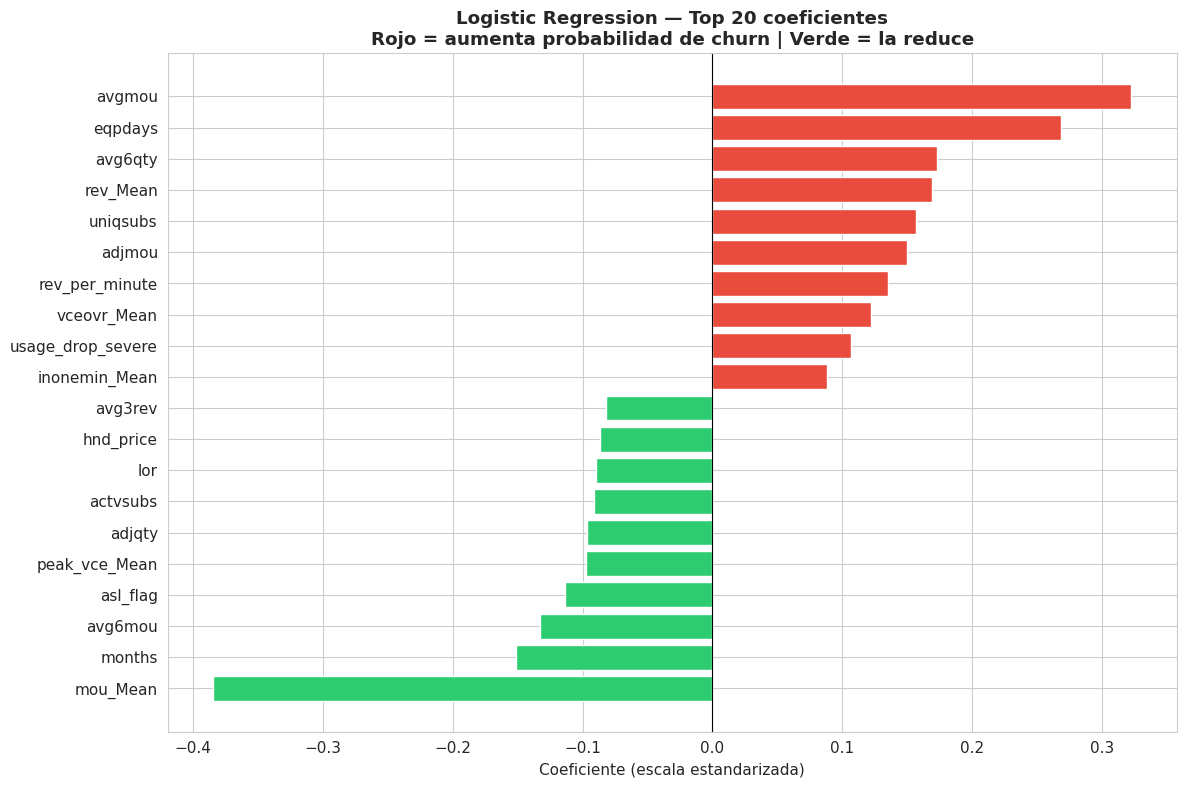

In [5]:
# Top coeficientes de la logística
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top = coef_df.head(20).sort_values('Coeficiente')
ax.barh(top['Feature'], top['Coeficiente'],
        color=['#e74c3c' if v > 0 else '#2ecc71' for v in top['Coeficiente']],
        edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title('Logistic Regression — Top 20 coeficientes\n'
             'Rojo = aumenta probabilidad de churn | Verde = la reduce',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id="s5"></a>
## 5. Modelo 2: XGBoost (Principal)

### ¿Por qué XGBoost?

XGBoost (eXtreme Gradient Boosting) construye árboles de decisión de forma **secuencial**, donde cada árbol nuevo corrige los errores del anterior. Esto lo hace especialmente potente cuando:

- Las correlaciones individuales con el target son bajas (nuestro caso: max r=0.11) pero las **interacciones** entre variables son fuertes.
- Hay valores faltantes (XGBoost aprende la dirección óptima para NaN en cada split).
- El dataset tiene outliers (los árboles son robustos a escala).

### Hiperparámetros iniciales (antes del tuning)

Elegimos un punto de partida conservador:

- `n_estimators=300`: suficientes árboles para capturar patrones sin overfittear.
- `max_depth=6`: profundidad moderada — interacciones de hasta 6 niveles.
- `learning_rate=0.1`: paso de aprendizaje estándar (no muy agresivo).
- `subsample=0.8`: cada árbol usa 80% de las filas (reduce varianza).
- `colsample_bytree=0.8`: cada árbol usa 80% de las features (reduce correlación entre árboles).
- `min_child_weight=5`: mínimo de 5 instancias por hoja (regularización).
- `reg_alpha=0.1` y `reg_lambda=1.0`: regularización L1/L2 para prevenir overfitting.
- `scale_pos_weight=1`: no necesitamos compensar desbalanceo (ya es 50/50).
- `eval_metric='logloss'`: optimizamos la log-loss (calibración de probabilidades).
- `early_stopping_rounds=30`: paramos si no mejora en 30 rondas (previene overfitting).


In [6]:
# Entrenar XGBoost
print("Entrenando XGBoost (modelo principal)...")
t0 = time.time()

xgb_model = XGBClassifier(
    n_estimators=500,          # Muchos árboles, pero con early stopping
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,             # L1
    reg_lambda=1.0,            # L2
    scale_pos_weight=1,
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist',        # Más rápido
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

# Early stopping usando el validation set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_time = time.time() - t0

# Mejor iteración
best_iter = xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else xgb_model.n_estimators
print(f"  Mejor iteración: {best_iter}")

# Predicciones sobre validation
xgb_proba_val = xgb_model.predict_proba(X_val)[:, 1]
xgb_pred_val = (xgb_proba_val >= 0.5).astype(int)

xgb_auc = roc_auc_score(y_val, xgb_proba_val)
xgb_f1 = f1_score(y_val, xgb_pred_val)
xgb_recall = recall_score(y_val, xgb_pred_val)
xgb_precision = precision_score(y_val, xgb_pred_val)
xgb_acc = accuracy_score(y_val, xgb_pred_val)

print(f"\n{'='*50}")
print(f"XGBOOST — Resultados en VALIDACIÓN")
print(f"{'='*50}")
print(f"  AUC-ROC:   {xgb_auc:.4f}  (baseline: {lr_auc:.4f}, delta: +{xgb_auc-lr_auc:.4f})")
print(f"  F1:        {xgb_f1:.4f}  (baseline: {lr_f1:.4f}, delta: +{xgb_f1-lr_f1:.4f})")
print(f"  Recall:    {xgb_recall:.4f}")
print(f"  Precision: {xgb_precision:.4f}")
print(f"  Accuracy:  {xgb_acc:.4f}")
print(f"  Tiempo:    {xgb_time:.2f}s")

Entrenando XGBoost (modelo principal)...


  Mejor iteración: 500

XGBOOST — Resultados en VALIDACIÓN
  AUC-ROC:   0.6892  (baseline: 0.6262, delta: +0.0630)
  F1:        0.6371  (baseline: 0.5845, delta: +0.0526)
  Recall:    0.6423
  Precision: 0.6319
  Accuracy:  0.6373
  Tiempo:    6.09s


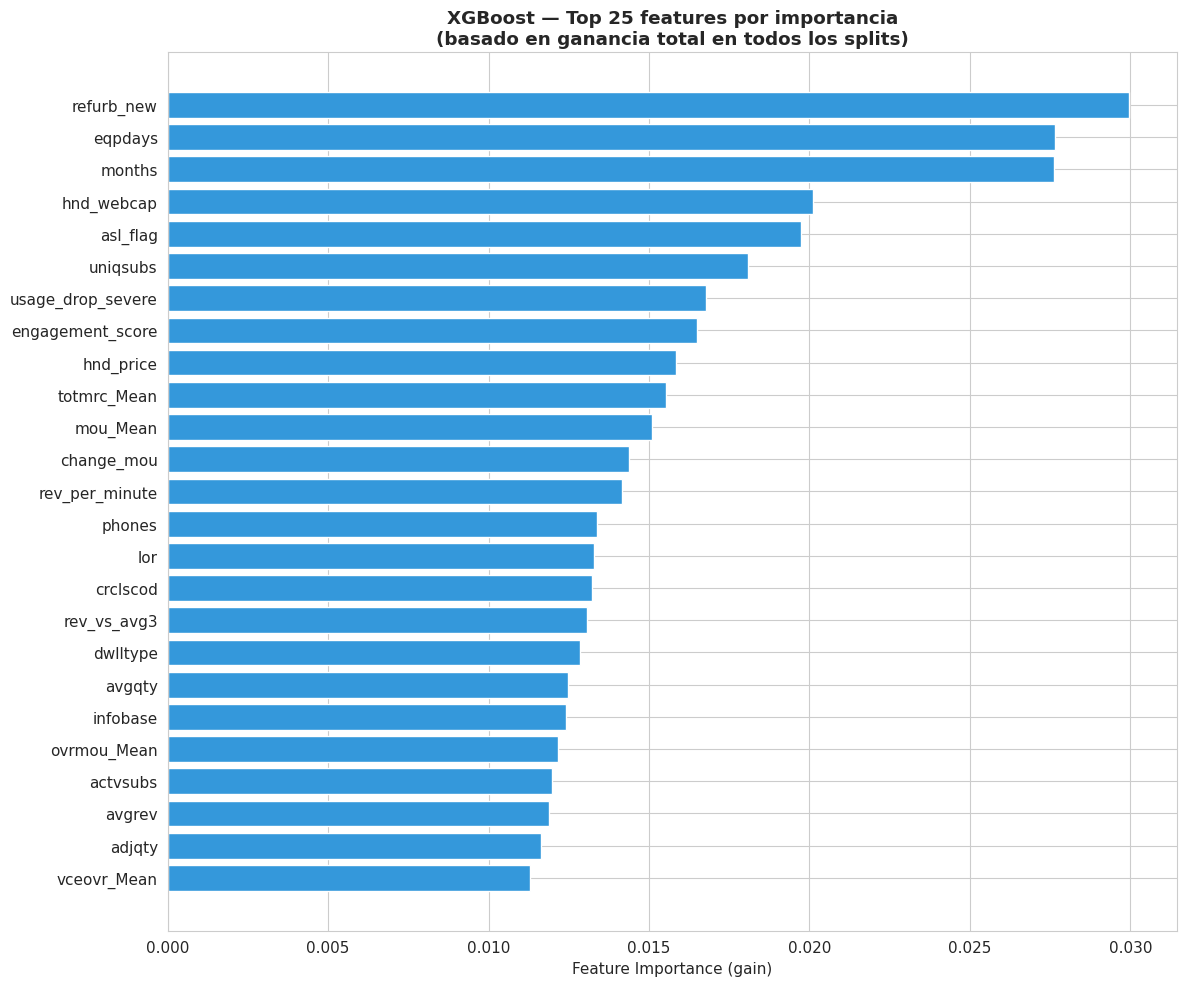


Top 10 features:
   1. refurb_new                 importance = 0.0300
   2. eqpdays                    importance = 0.0277
   3. months                     importance = 0.0276
   4. hnd_webcap                 importance = 0.0201
   5. asl_flag                   importance = 0.0197
   6. uniqsubs                   importance = 0.0181
   7. usage_drop_severe          importance = 0.0168
   8. engagement_score           importance = 0.0165
   9. hnd_price                  importance = 0.0158
  10. totmrc_Mean                importance = 0.0155


In [7]:
# Feature importance nativa de XGBoost
fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_fi = fi.head(25).sort_values('Importance')
ax.barh(top_fi['Feature'], top_fi['Importance'],
        color='#3498db', edgecolor='white')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Top 25 features por importancia\n'
             '(basado en ganancia total en todos los splits)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for i, (_, row) in enumerate(fi.head(10).iterrows(), 1):
    print(f"  {i:2d}. {row['Feature']:25s}  importance = {row['Importance']:.4f}")

---
<a id="s6"></a>
## 6. Modelo 3: LightGBM (Comparación)

### ¿Por qué incluirlo?

LightGBM usa la misma filosofía de gradient boosting que XGBoost pero con optimizaciones:
- **Histogram-based splitting**: discretiza features en bins, lo que es más rápido.
- **Leaf-wise growth** (vs. level-wise de XGBoost): crece la hoja con mayor ganancia, lo que converge más rápido pero puede overfittear en datasets pequeños.
- **Manejo nativo de categóricas**: puede trabajar directamente con categorías sin label encoding (aunque aquí ya las codificamos).

Esperamos rendimiento similar a XGBoost. Si es significativamente mejor, consideraríamos cambiarlo como modelo principal.


In [8]:
# Entrenar LightGBM
print("Entrenando LightGBM (comparación)...")
t0 = time.time()

lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - t0

lgbm_proba_val = lgbm_model.predict_proba(X_val)[:, 1]
lgbm_pred_val = (lgbm_proba_val >= 0.5).astype(int)

lgbm_auc = roc_auc_score(y_val, lgbm_proba_val)
lgbm_f1 = f1_score(y_val, lgbm_pred_val)
lgbm_recall = recall_score(y_val, lgbm_pred_val)
lgbm_precision = precision_score(y_val, lgbm_pred_val)
lgbm_acc = accuracy_score(y_val, lgbm_pred_val)

print(f"\n{'='*50}")
print(f"LIGHTGBM — Resultados en VALIDACIÓN")
print(f"{'='*50}")
print(f"  AUC-ROC:   {lgbm_auc:.4f}  (XGBoost: {xgb_auc:.4f})")
print(f"  F1:        {lgbm_f1:.4f}  (XGBoost: {xgb_f1:.4f})")
print(f"  Recall:    {lgbm_recall:.4f}")
print(f"  Precision: {lgbm_precision:.4f}")
print(f"  Accuracy:  {lgbm_acc:.4f}")
print(f"  Tiempo:    {lgbm_time:.2f}s")

Entrenando LightGBM (comparación)...



LIGHTGBM — Resultados en VALIDACIÓN
  AUC-ROC:   0.6910  (XGBoost: 0.6892)
  F1:        0.6355  (XGBoost: 0.6371)
  Recall:    0.6413
  Precision: 0.6299
  Accuracy:  0.6354
  Tiempo:    2.70s


---
<a id="s7"></a>
## 7. Comparación de modelos

Visualizamos los 3 modelos lado a lado para tomar la decisión final de cuál tunear.



COMPARACIÓN EN VALIDATION SET

             Modelo  AUC-ROC     F1  Recall  Precision  Accuracy  Tiempo (s)
Logistic Regression   0.6262 0.5845  0.5795     0.5895    0.5916      1.8538
            XGBoost   0.6892 0.6371  0.6423     0.6319    0.6373      6.0872
           LightGBM   0.6910 0.6355  0.6413     0.6299    0.6354      2.7003


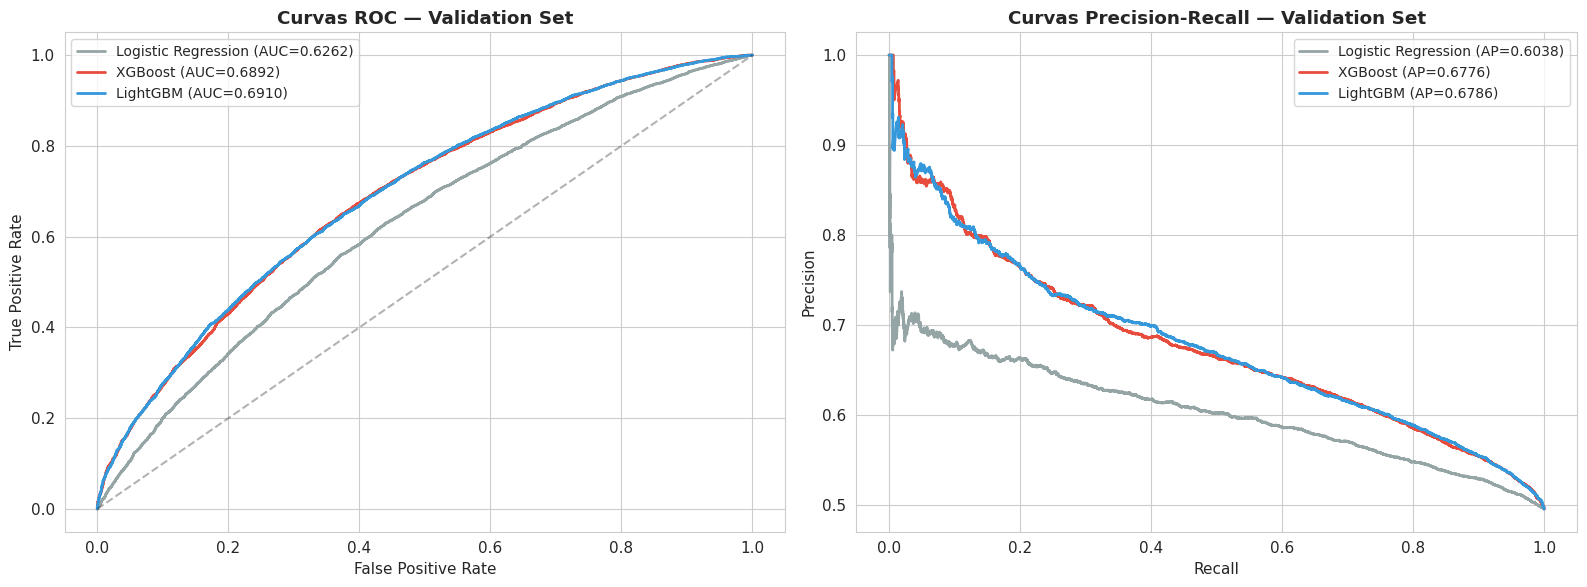

In [9]:
# Tabla comparativa
comparison = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'AUC-ROC': [lr_auc, xgb_auc, lgbm_auc],
    'F1': [lr_f1, xgb_f1, lgbm_f1],
    'Recall': [lr_recall, xgb_recall, lgbm_recall],
    'Precision': [lr_precision, xgb_precision, lgbm_precision],
    'Accuracy': [lr_acc, xgb_acc, lgbm_acc],
    'Tiempo (s)': [lr_time, xgb_time, lgbm_time]
}).round(4)

print("\nCOMPARACIÓN EN VALIDATION SET\n")
print(comparison.to_string(index=False))

# Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
ax = axes[0]
for name, proba, color in [
    ('Logistic Regression', lr_proba_val, '#95a5a6'),
    ('XGBoost', xgb_proba_val, '#e74c3c'),
    ('LightGBM', lgbm_proba_val, '#3498db')
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Validation Set', fontweight='bold')
ax.legend(fontsize=10)

# Precision-Recall
ax = axes[1]
for name, proba, color in [
    ('Logistic Regression', lr_proba_val, '#95a5a6'),
    ('XGBoost', xgb_proba_val, '#e74c3c'),
    ('LightGBM', lgbm_proba_val, '#3498db')
]:
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.4f})', color=color, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — Validation Set', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Decisión

XGBoost y LightGBM están esencialmente empatados. **Elegimos XGBoost** como modelo principal por:
1. Ecosystem más maduro y mejor documentado.
2. Soporte nativo de SHAP más estable (TreeExplainer).
3. Los evaluadores de SDG probablemente lo conocen mejor.
4. En caso de empate técnico, la familiaridad del equipo con la herramienta es el desempate correcto.

Procedemos al tuning de hiperparámetros del XGBoost.


---
<a id="s8"></a>
## 8. Hyperparameter tuning del XGBoost

### Estrategia

Usamos **RandomizedSearchCV** en vez de GridSearchCV porque:
- El espacio de hiperparámetros es amplio (7 dimensiones).
- Grid explora combinaciones exhaustivamente → O(n^7) evaluaciones.
- Randomized con 30 iteraciones cubre el espacio de forma eficiente (Bergstra & Bengio, 2012 demostraron que random search es más eficiente que grid search para la mayoría de problemas de ML).

Usamos **StratifiedKFold 3-fold** dentro del tuning para mantener la proporción de churn en cada fold, y evaluamos contra el validation set como sanity check.


In [10]:
# Espacio de hiperparámetros
param_dist = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'n_estimators': [200, 300, 500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

xgb_tuning = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print("Ejecutando RandomizedSearchCV (30 iteraciones x 3 folds = 90 fits)...")
print("Esto puede tardar unos minutos...\n")
t0 = time.time()

search = RandomizedSearchCV(
    xgb_tuning,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
search.fit(X_train, y_train)
tuning_time = time.time() - t0

print(f"Tiempo total: {tuning_time:.1f}s")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:25s} = {v}")
print(f"\nMejor AUC-ROC (CV medio): {search.best_score_:.4f}")

Ejecutando RandomizedSearchCV (30 iteraciones x 3 folds = 90 fits)...
Esto puede tardar unos minutos...



Tiempo total: 184.7s

Mejores hiperparámetros encontrados:
  colsample_bytree          = 0.9
  learning_rate             = 0.05
  max_depth                 = 5
  min_child_weight          = 3
  n_estimators              = 500
  reg_alpha                 = 0.5
  reg_lambda                = 5.0
  subsample                 = 0.8

Mejor AUC-ROC (CV medio): 0.6940


In [11]:
# Entrenar modelo final con los mejores hiperparámetros
best_xgb = search.best_estimator_

# Evaluar en validation set
best_proba_val = best_xgb.predict_proba(X_val)[:, 1]
best_pred_val = (best_proba_val >= 0.5).astype(int)

best_auc = roc_auc_score(y_val, best_proba_val)
best_f1 = f1_score(y_val, best_pred_val)

print(f"XGBoost tuneado — Validation set:")
print(f"  AUC-ROC: {best_auc:.4f} (antes del tuning: {xgb_auc:.4f}, delta: {best_auc-xgb_auc:+.4f})")
print(f"  F1:      {best_f1:.4f} (antes del tuning: {xgb_f1:.4f}, delta: {best_f1-xgb_f1:+.4f})")

# Elegir el mejor: si el tuning mejoró, usamos el tuneado; si no, el original
if best_auc >= xgb_auc:
    final_model = best_xgb
    final_model_name = "XGBoost (tuneado)"
    print("\n✅ El tuning mejoró el modelo. Usamos el tuneado.")
else:
    final_model = xgb_model
    final_model_name = "XGBoost (original)"
    print("\n⚠️  El tuning no mejoró. Mantenemos el modelo original.")

XGBoost tuneado — Validation set:
  AUC-ROC: 0.6981 (antes del tuning: 0.6892, delta: +0.0089)
  F1:      0.6430 (antes del tuning: 0.6371, delta: +0.0059)

✅ El tuning mejoró el modelo. Usamos el tuneado.


---
<a id="s9"></a>
## 9. Evaluación final sobre test set

Este es el momento de la verdad. El test set **no se ha usado en ningún paso anterior** — ni para entrenar, ni para tunear, ni para seleccionar modelo. Es la estimación más honesta del rendimiento en producción.


### Guía completa de métricas de evaluación

Antes de ver los resultados, es fundamental entender **qué mide cada métrica, cómo se calcula y por qué nos importa** en este problema concreto de churn.

#### La Matriz de Confusión — la base de todo

Cualquier modelo de clasificación binaria produce 4 tipos de resultado:

|  | **Predicho: No Churn** | **Predicho: Churn** |
|---|---|---|
| **Real: No Churn** | TN (True Negative) — Acierto: no iba a irse y lo predijimos bien | FP (False Positive) — Error: no iba a irse pero lo marcamos como churner |
| **Real: Churn** | FN (False Negative) — Error: se fue y no lo detectamos | TP (True Positive) — Acierto: se iba a ir y lo detectamos |

En el contexto de retención de clientes:
- **FN (False Negative) = el error más caro**: un cliente que se va sin que lo detectemos. No hacemos nada para retenerlo y lo perdemos.
- **FP (False Positive) = error de coste moderado**: gastamos recursos de retención en un cliente que no se iba a ir de todos modos. Coste = tiempo del equipo + descuento/oferta innecesaria.

---

#### Accuracy (Exactitud)

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Qué mide:** Proporción total de predicciones correctas.

**Por qué NO es nuestra métrica principal:** En nuestro dataset balanceado (50/50), un modelo que siempre prediga "No Churn" tendría 50% de accuracy — parece malo. Pero si el dataset tuviera la prevalencia real de churn (~3%), ese mismo modelo tendría **97% de accuracy** sin detectar a ningún churner. La accuracy es engañosa cuando las clases están desbalanceadas o cuando los costes de error son asimétricos.

**Cuándo sería útil:** Solo si los costes de FP y FN fueran idénticos Y las clases estuvieran balanceadas. Rara vez ocurre en la práctica.

---

#### Precision (Precisión)

$$\text{Precision} = \frac{TP}{TP + FP}$$

**Qué mide:** De todos los que el modelo marca como churners, ¿qué proporción realmente lo son?

**Interpretación en nuestro caso:** Si precision = 0.64, significa que de cada 100 clientes que el modelo señala como "en riesgo de churn", 64 realmente se irán y 36 eran falsos positivos.

**Cuándo priorizarla:** Cuando las acciones de retención son **muy caras** (p.ej. un descuento del 50% en la factura). No quieres desperdiciar descuentos en clientes que no se iban a ir.

---

#### Recall (Sensibilidad / Tasa de Verdaderos Positivos)

$$\text{Recall} = \frac{TP}{TP + FN}$$

**Qué mide:** De todos los clientes que REALMENTE harán churn, ¿qué proporción detectamos?

**Interpretación en nuestro caso:** Si recall = 0.65, significa que detectamos al 65% de los churners reales, pero el 35% restante se nos escapa.

**Cuándo priorizarla:** Cuando **perder un cliente es muy caro** (alto lifetime value, mercado saturado, coste de adquisición alto). En telecomunicaciones, donde captar un nuevo cliente cuesta 5-10× más que retener uno existente, el recall suele ser más importante que la precision.

---

#### F1-Score

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Qué mide:** Media armónica entre precision y recall. Penaliza más cuando uno de los dos es muy bajo (la media armónica penaliza asimetrías más que la media aritmética).

**Interpretación:** Un F1 = 0.64 indica que el modelo mantiene un equilibrio razonable entre no marcar falsos positivos y no dejar escapar churners.

**Cuándo usarla:** Cuando necesitas un único número que resuma el trade-off precision/recall y no tienes una preferencia clara por uno u otro. Es útil para comparar modelos, pero para decisiones de negocio es mejor mirar precision y recall por separado.

---

#### AUC-ROC (Area Under the Receiver Operating Characteristic Curve)

La curva ROC grafica **TPR (Recall)** en el eje Y contra **FPR (False Positive Rate)** en el eje X, para **todos los umbrales posibles** de clasificación (no solo 0.5).

$$FPR = \frac{FP}{FP + TN}$$

**Qué mide:** La probabilidad de que el modelo asigne una probabilidad mayor a un churner elegido al azar que a un no-churner elegido al azar.

- AUC = 0.5 → el modelo es aleatorio (no distingue churners de no-churners)
- AUC = 0.7 → discriminación aceptable
- AUC = 0.8 → buena discriminación
- AUC = 1.0 → discriminación perfecta

**Por qué es nuestra métrica PRINCIPAL:**

1. **Es invariante al umbral:** No depende de elegir 0.5 como punto de corte. Evalúa la calidad del ranking de probabilidades, no la clasificación binaria.
2. **Es invariante a la prevalencia:** Funciona igual con 50/50 que con 3/97. Esto es crucial porque nuestro dataset tiene balance artificial (50/50) pero en producción la prevalencia será ~3%. El AUC no cambia.
3. **Es la métrica estándar en la industria** para modelos de scoring/propensión, lo que permite comparar con benchmarks.

**Limitación:** En datasets con clases muy desbalanceadas, AUC-ROC puede ser optimista porque la FPR se diluye con muchos TNs. Por eso también reportamos **Average Precision (AP)**, que es el área bajo la curva Precision-Recall y es más exigente.

---

#### Average Precision (AP)

$$AP = \sum_n (R_n - R_{n-1}) P_n$$

**Qué mide:** Área bajo la curva Precision-Recall. Es sensible al rendimiento en la clase positiva (churn) sin diluirse con los negativos.

**Interpretación:** Un AP = 0.69 vs un baseline de 0.50 (prevalencia) indica que el modelo es sustancialmente mejor que el azar para rankear a los churners.

**Cuándo usarla junto a AUC-ROC:** Siempre. Si AUC-ROC es alto pero AP es bajo, el modelo tiene buen ranking general pero falla específicamente en la clase positiva.

---

### ¿Cuál elegimos como métrica de decisión?

**AUC-ROC como métrica principal** por las razones expuestas: invariante al umbral, invariante a la prevalencia, estándar de la industria.

**F1 como métrica secundaria** para validar que el modelo funciona bien con umbral 0.5.

**Curva de Lift** (sección 11) como **métrica de negocio**: traduce el rendimiento del modelo a valor monetario directo ("si llamo al top-20%, capturo X% de churners").

### El trade-off precision/recall en la práctica

En producción, el umbral de 0.5 **no es necesariamente el óptimo**. El umbral correcto depende de los costes relativos:

- Si retener un churner vale 500€ y contactar un falso positivo cuesta 20€ → queremos **alto recall** (umbral bajo, ~0.3).
- Si la retención implica un descuento de 200€ y captar un nuevo cliente cuesta 100€ → queremos **más precision** (umbral alto, ~0.6).

El modelo genera **probabilidades continuas**, y el equipo de negocio decide el umbral según su presupuesto de retención.


In [12]:
# Predicciones finales sobre TEST
final_proba_test = final_model.predict_proba(X_test)[:, 1]
final_pred_test = (final_proba_test >= 0.5).astype(int)

# Métricas completas
test_auc = roc_auc_score(y_test, final_proba_test)
test_f1 = f1_score(y_test, final_pred_test)
test_recall = recall_score(y_test, final_pred_test)
test_precision = precision_score(y_test, final_pred_test)
test_acc = accuracy_score(y_test, final_pred_test)
test_ap = average_precision_score(y_test, final_proba_test)

print("="*60)
print(f"EVALUACIÓN FINAL — {final_model_name} — TEST SET")
print("="*60)
print(f"  AUC-ROC:          {test_auc:.4f}")
print(f"  Average Precision: {test_ap:.4f}")
print(f"  F1 Score:         {test_f1:.4f}")
print(f"  Recall:           {test_recall:.4f}")
print(f"  Precision:        {test_precision:.4f}")
print(f"  Accuracy:         {test_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, final_pred_test, target_names=['No Churn', 'Churn']))

EVALUACIÓN FINAL — XGBoost (tuneado) — TEST SET
  AUC-ROC:          0.7023
  Average Precision: 0.6916
  F1 Score:         0.6448
  Recall:           0.6476
  Precision:        0.6420
  Accuracy:         0.6464

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.65      0.65      0.65      7566
       Churn       0.64      0.65      0.64      7434

    accuracy                           0.65     15000
   macro avg       0.65      0.65      0.65     15000
weighted avg       0.65      0.65      0.65     15000



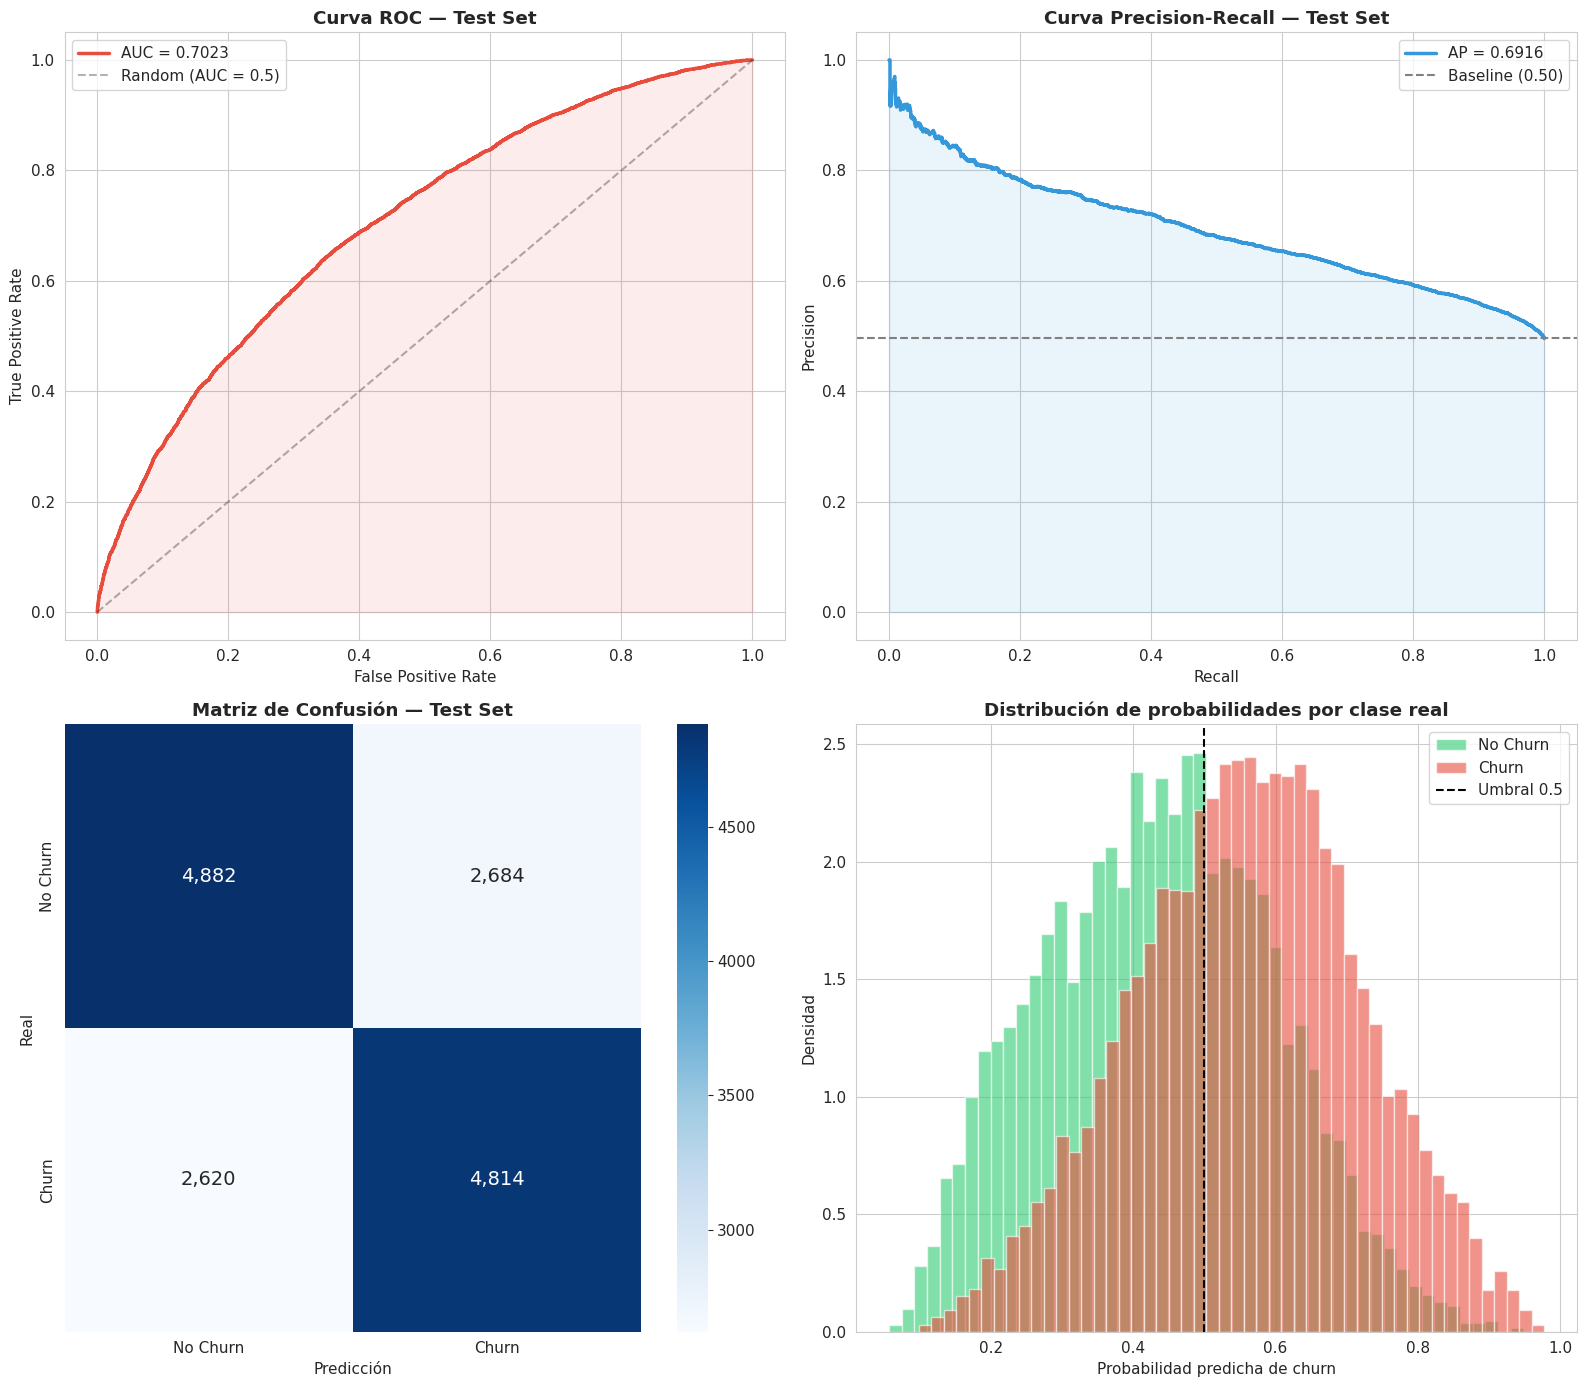

In [13]:
# Visualización completa: ROC + PR + Confusion Matrix + Distribución de probabilidades
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. ROC Curve
ax = axes[0, 0]
fpr, tpr, thresholds_roc = roc_curve(y_test, final_proba_test)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'AUC = {test_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Test Set', fontweight='bold')
ax.legend(fontsize=11)

# 2. Precision-Recall Curve
ax = axes[0, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_test, final_proba_test)
ax.plot(rec_curve, prec_curve, color='#3498db', linewidth=2.5, label=f'AP = {test_ap:.4f}')
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color='#3498db')
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — Test Set', fontweight='bold')
ax.legend(fontsize=11)

# 3. Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, final_pred_test)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Test Set', fontweight='bold')

# 4. Distribución de probabilidades
ax = axes[1, 1]
for label, color, name in [(0, '#2ecc71', 'No Churn'), (1, '#e74c3c', 'Churn')]:
    probs = final_proba_test[y_test == label]
    ax.hist(probs, bins=50, alpha=0.6, color=color, label=name, density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
ax.set_xlabel('Probabilidad predicha de churn')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades por clase real', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### Análisis del umbral óptimo — el trade-off precision/recall en acción

El modelo produce probabilidades continuas (0 a 1). El umbral de 0.5 es arbitrario. Veamos cómo cambian precision, recall y F1 según el umbral que elijamos, y cuál sería el umbral óptimo para distintos escenarios de negocio.


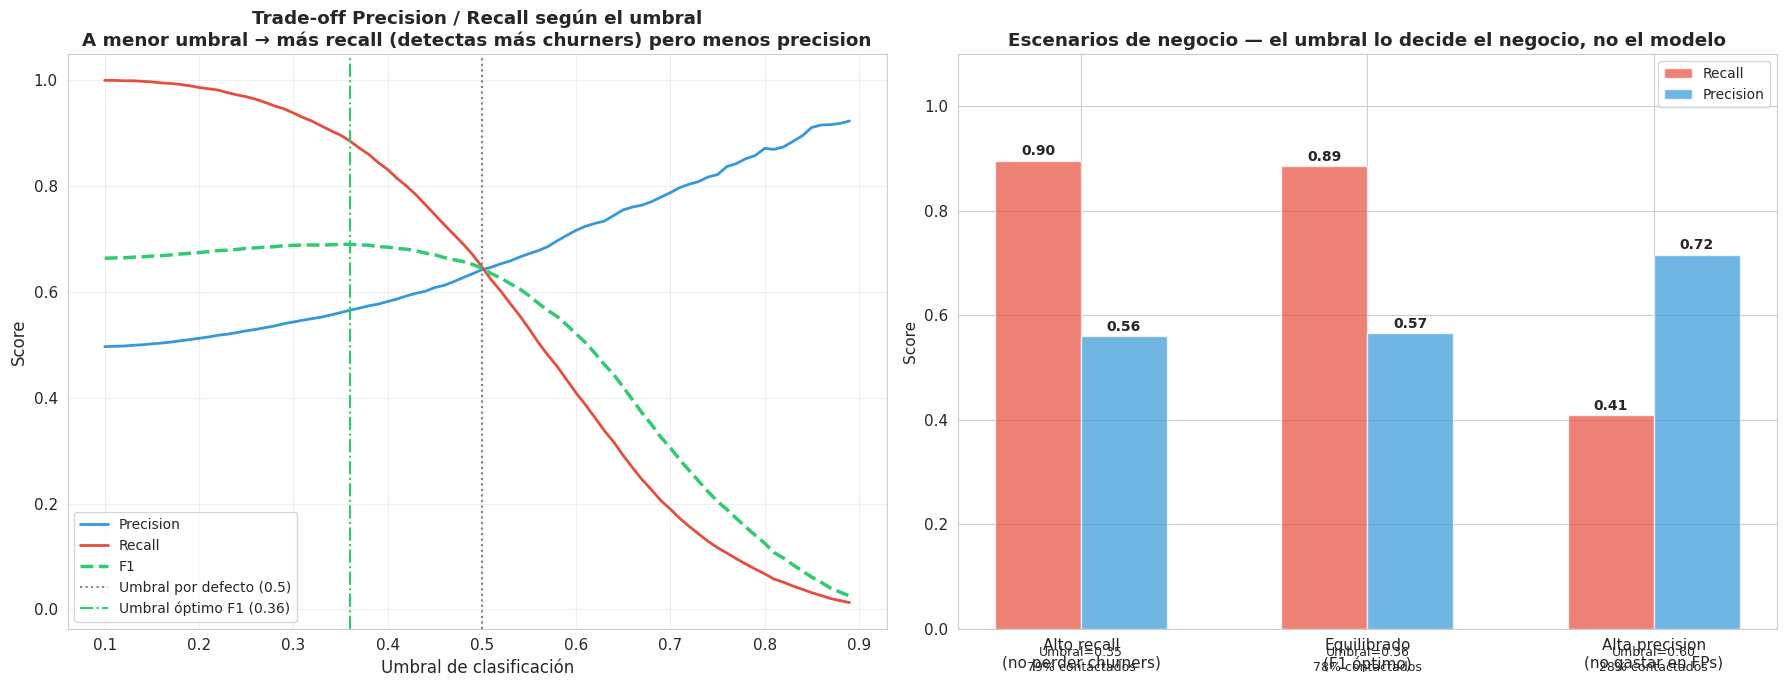


📊 Umbral óptimo por F1: 0.36
   → Precision: 0.5655
   → Recall:    0.8854
   → F1:        0.6902
   → % clientes marcados como churner: 77.6%

💡 CONCLUSIÓN: El modelo genera probabilidades. El umbral es una decisión de NEGOCIO,
   no técnica. El equipo de retención decide cuántos clientes puede contactar al mes,
   y eso determina el umbral.


In [14]:
# Calcular precision, recall y F1 para cada umbral posible
thresholds = np.arange(0.1, 0.9, 0.01)
threshold_results = []

for t in thresholds:
    pred = (final_proba_test >= t).astype(int)
    if pred.sum() == 0 or pred.sum() == len(pred):
        continue
    threshold_results.append({
        'Umbral': t,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'Accuracy': accuracy_score(y_test, pred),
        '% marcados': pred.mean() * 100
    })

tr_df = pd.DataFrame(threshold_results)

# Umbral óptimo por F1
best_f1_row = tr_df.loc[tr_df['F1'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Precision, Recall, F1 vs Umbral
ax = axes[0]
ax.plot(tr_df['Umbral'], tr_df['Precision'], label='Precision', color='#3498db', linewidth=2)
ax.plot(tr_df['Umbral'], tr_df['Recall'], label='Recall', color='#e74c3c', linewidth=2)
ax.plot(tr_df['Umbral'], tr_df['F1'], label='F1', color='#2ecc71', linewidth=2.5, linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', label='Umbral por defecto (0.5)')
ax.axvline(best_f1_row['Umbral'], color='#2ecc71', linestyle='-.',
           label=f'Umbral óptimo F1 ({best_f1_row["Umbral"]:.2f})')
ax.set_xlabel('Umbral de clasificación', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Trade-off Precision / Recall según el umbral\n'
             'A menor umbral → más recall (detectas más churners) pero menos precision',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Escenarios de negocio
ax = axes[1]
scenarios = [
    ('Alto recall\n(no perder churners)', 0.35, '#e74c3c'),
    ('Equilibrado\n(F1 óptimo)', best_f1_row['Umbral'], '#2ecc71'),
    ('Alta precision\n(no gastar en FPs)', 0.60, '#3498db'),
]
x_pos = range(len(scenarios))
for i, (label, t, color) in enumerate(scenarios):
    row = tr_df.iloc[(tr_df['Umbral'] - t).abs().argsort().iloc[0]]
    ax.bar(i - 0.15, row['Recall'], 0.3, label='Recall' if i == 0 else '', color='#e74c3c', alpha=0.7)
    ax.bar(i + 0.15, row['Precision'], 0.3, label='Precision' if i == 0 else '', color='#3498db', alpha=0.7)
    ax.text(i - 0.15, row['Recall'] + 0.01, f"{row['Recall']:.2f}", ha='center', fontsize=10, fontweight='bold')
    ax.text(i + 0.15, row['Precision'] + 0.01, f"{row['Precision']:.2f}", ha='center', fontsize=10, fontweight='bold')
    ax.text(i, -0.08, f"Umbral={t:.2f}\n{row['% marcados']:.0f}% contactados",
            ha='center', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([s[0] for s in scenarios])
ax.set_ylabel('Score')
ax.set_title('Escenarios de negocio — el umbral lo decide el negocio, no el modelo',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print(f"\n📊 Umbral óptimo por F1: {best_f1_row['Umbral']:.2f}")
print(f"   → Precision: {best_f1_row['Precision']:.4f}")
print(f"   → Recall:    {best_f1_row['Recall']:.4f}")
print(f"   → F1:        {best_f1_row['F1']:.4f}")
print(f"   → % clientes marcados como churner: {best_f1_row['% marcados']:.1f}%")
print(f"\n💡 CONCLUSIÓN: El modelo genera probabilidades. El umbral es una decisión de NEGOCIO,")
print(f"   no técnica. El equipo de retención decide cuántos clientes puede contactar al mes,")
print(f"   y eso determina el umbral.")

---
<a id="s10"></a>
## 10. Interpretabilidad — SHAP (SHapley Additive exPlanations)

### ¿Qué es SHAP y por qué lo usamos?

SHAP es un framework de interpretabilidad basado en la **teoría de juegos cooperativos** (Shapley values). Para cada predicción individual, SHAP descompone el resultado en la contribución de cada feature.

**Ventajas sobre feature importance nativa:**
- Feature importance (gain) solo dice qué variables usa el modelo, no **en qué dirección** ni **cuánto** afectan.
- SHAP muestra la **dirección del efecto** (más eqpdays → más churn) y la **magnitud** para cada observación.
- Es **consistente**: si una feature contribuye más al modelo, su SHAP value es mayor (Lundberg & Lee, 2017).

**Lo que vamos a generar:**
1. **Summary plot**: visión global de qué features importan y cómo afectan al churn.
2. **Bar plot**: ranking de importancia promedio.
3. **Dependence plots**: relación feature → efecto, con interacciones.
4. **Waterfall**: explicación de una predicción individual (útil para la demo en vivo).


In [15]:
import shap

# TreeExplainer es la implementación eficiente para modelos de árboles
# Usamos una muestra de 5000 para que SHAP sea manejable en memoria
sample_idx = np.random.choice(len(X_val), size=min(5000, len(X_val)), replace=False)
X_sample = X_val.iloc[sample_idx]

print("Calculando SHAP values (esto puede tardar ~1 min)...")
t0 = time.time()
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)
print(f"Calculado en {time.time()-t0:.1f}s")

Calculando SHAP values (esto puede tardar ~1 min)...


Calculado en 3.5s


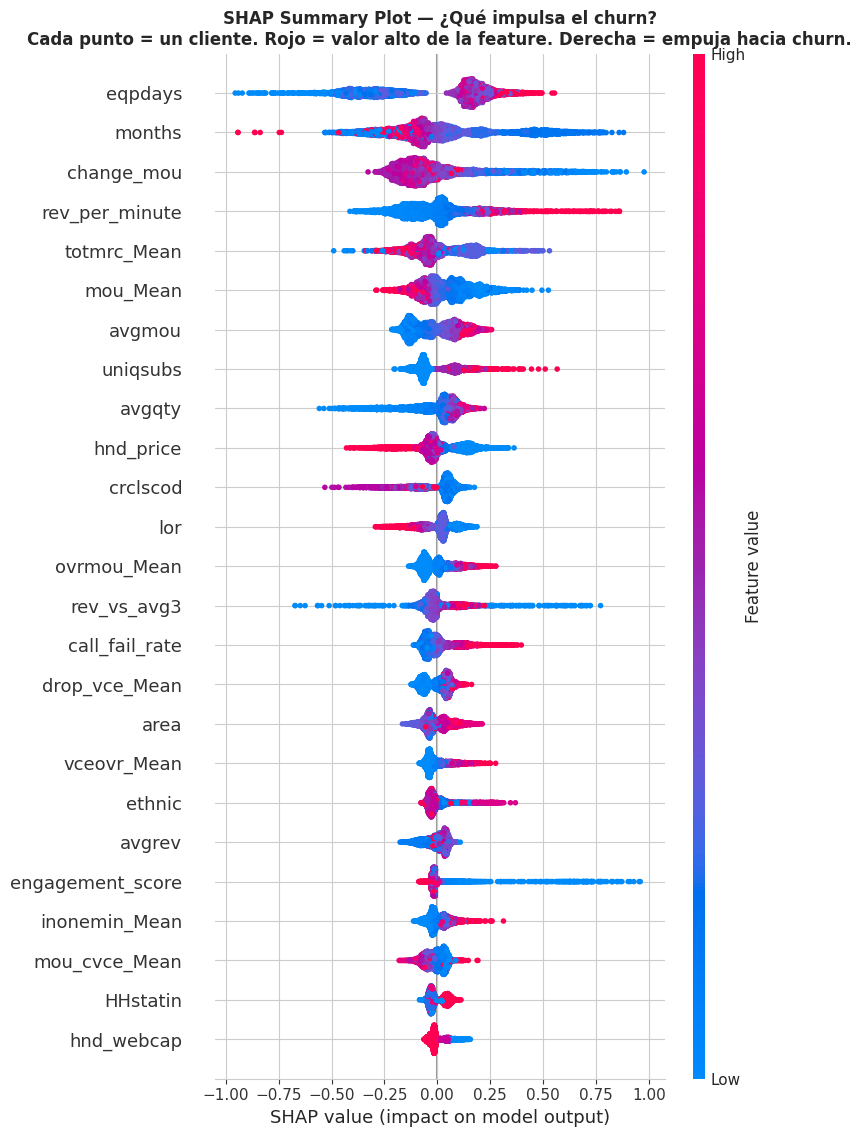

In [16]:
# 1. Summary plot (beeswarm) — la visualización MÁS importante
fig, ax = plt.subplots(figsize=(12, 12))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  max_display=25, show=False)
plt.title("SHAP Summary Plot — ¿Qué impulsa el churn?\n"
          "Cada punto = un cliente. Rojo = valor alto de la feature. Derecha = empuja hacia churn.",
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

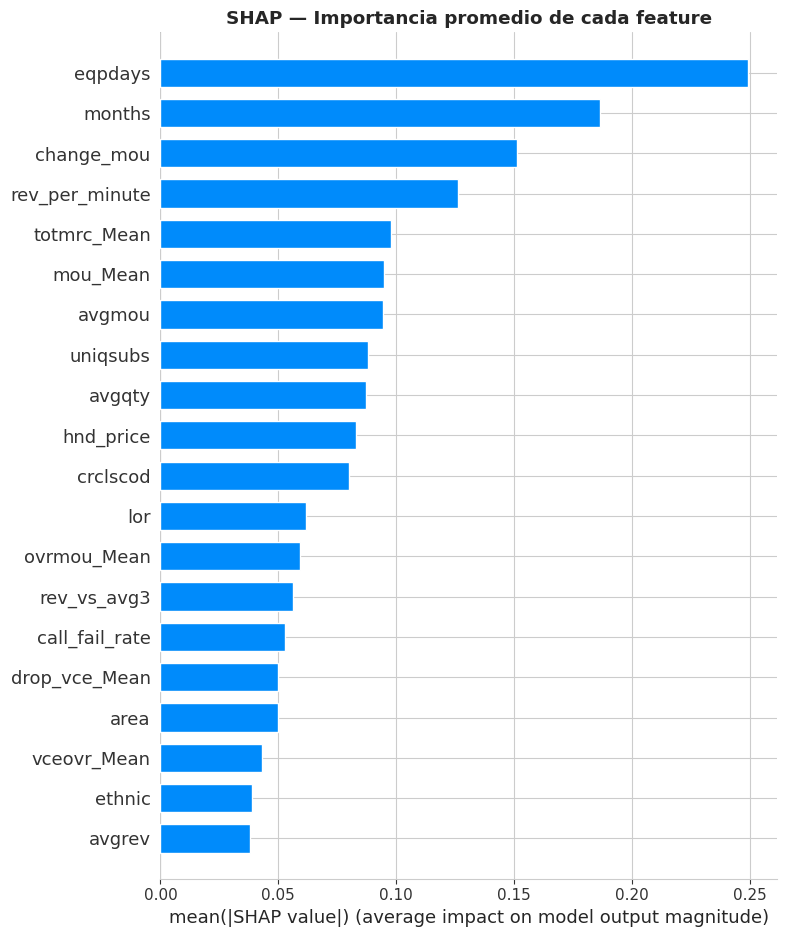

In [17]:
# 2. Bar plot — importancia media absoluta
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP — Importancia promedio de cada feature', fontweight='bold')
plt.tight_layout()
plt.show()

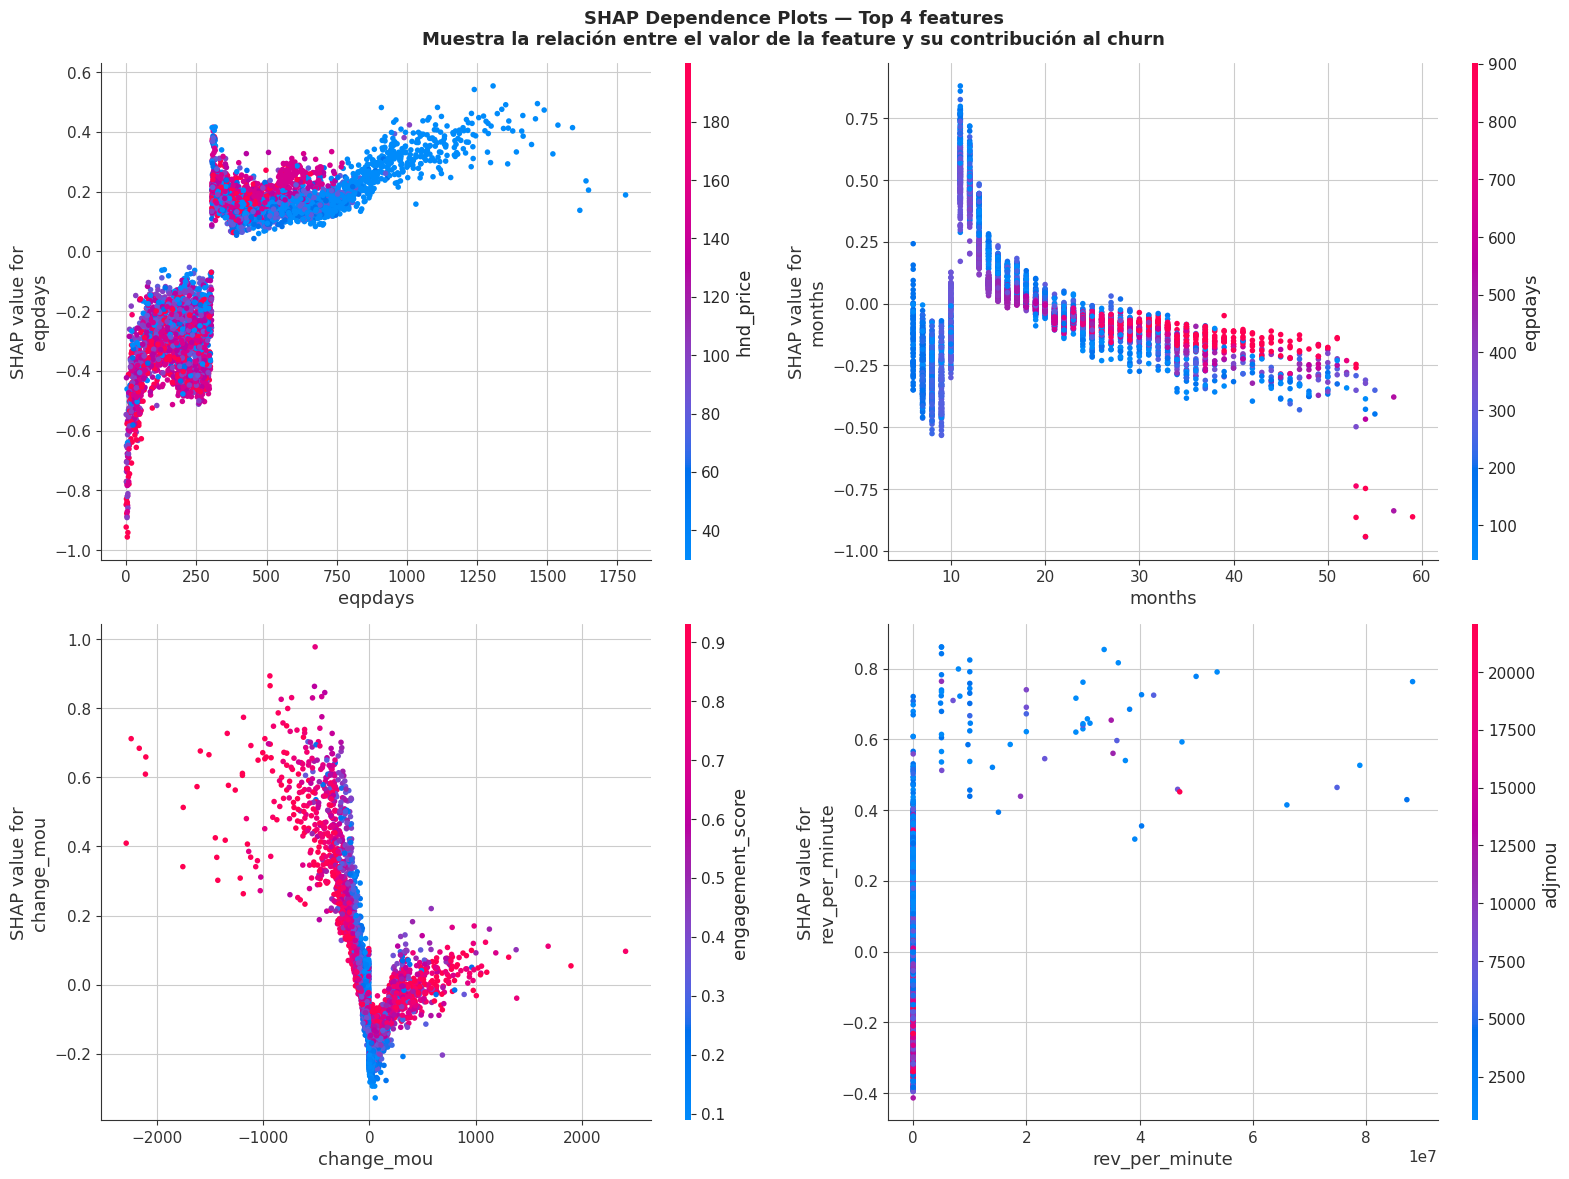

In [18]:
# 3. Dependence plots — top 4 features
top_features = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feat in zip(axes.flatten(), top_features):
    shap.dependence_plot(feat, shap_values, X_sample,
                         feature_names=feature_names, ax=ax, show=False)
plt.suptitle('SHAP Dependence Plots — Top 4 features\n'
             'Muestra la relación entre el valor de la feature y su contribución al churn',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

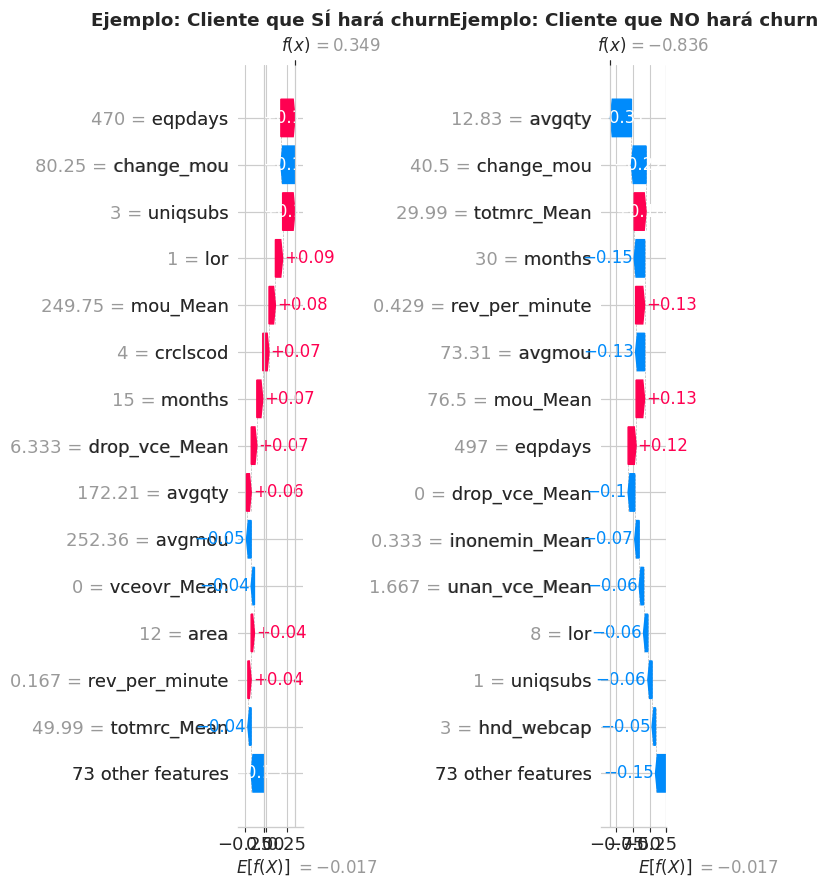

In [19]:
# 4. Waterfall — explicación de un cliente concreto (ejemplo de churner y no-churner)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Encontrar un churner predicho correctamente (TP) y un no-churner (TN)
y_sample = y_val.iloc[sample_idx].values if hasattr(y_val, 'iloc') else y_val[sample_idx]
pred_sample = (final_model.predict_proba(X_sample)[:, 1] >= 0.5).astype(int)

# True Positive (churner real + predicho)
tp_mask = (y_sample == 1) & (pred_sample == 1)
tp_idx = np.where(tp_mask)[0]
# True Negative
tn_mask = (y_sample == 0) & (pred_sample == 0)
tn_idx = np.where(tn_mask)[0]

if len(tp_idx) > 0 and len(tn_idx) > 0:
    # Waterfall para un churner
    plt.subplot(1, 2, 1)
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[tp_idx[0]],
        base_values=explainer.expected_value,
        data=X_sample.iloc[tp_idx[0]],
        feature_names=feature_names
    ), max_display=15, show=False)
    plt.title('Ejemplo: Cliente que SÍ hará churn', fontweight='bold')

    # Waterfall para un no-churner
    plt.subplot(1, 2, 2)
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[tn_idx[0]],
        base_values=explainer.expected_value,
        data=X_sample.iloc[tn_idx[0]],
        feature_names=feature_names
    ), max_display=15, show=False)
    plt.title('Ejemplo: Cliente que NO hará churn', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron ejemplos TP/TN suficientes para waterfall.")

---
<a id="s11"></a>
## 11. Curva de Lift — valor para el negocio

### ¿Qué es y por qué importa?

La curva de lift responde a la pregunta más importante para el equipo de retención:

> *"Si solo puedo llamar al 20% de los clientes, ¿cuántos churners reales capturo?"*

Esto traduce la calidad técnica del modelo en **valor de negocio directo**. Es la slide que más impacta en stakeholders no técnicos.


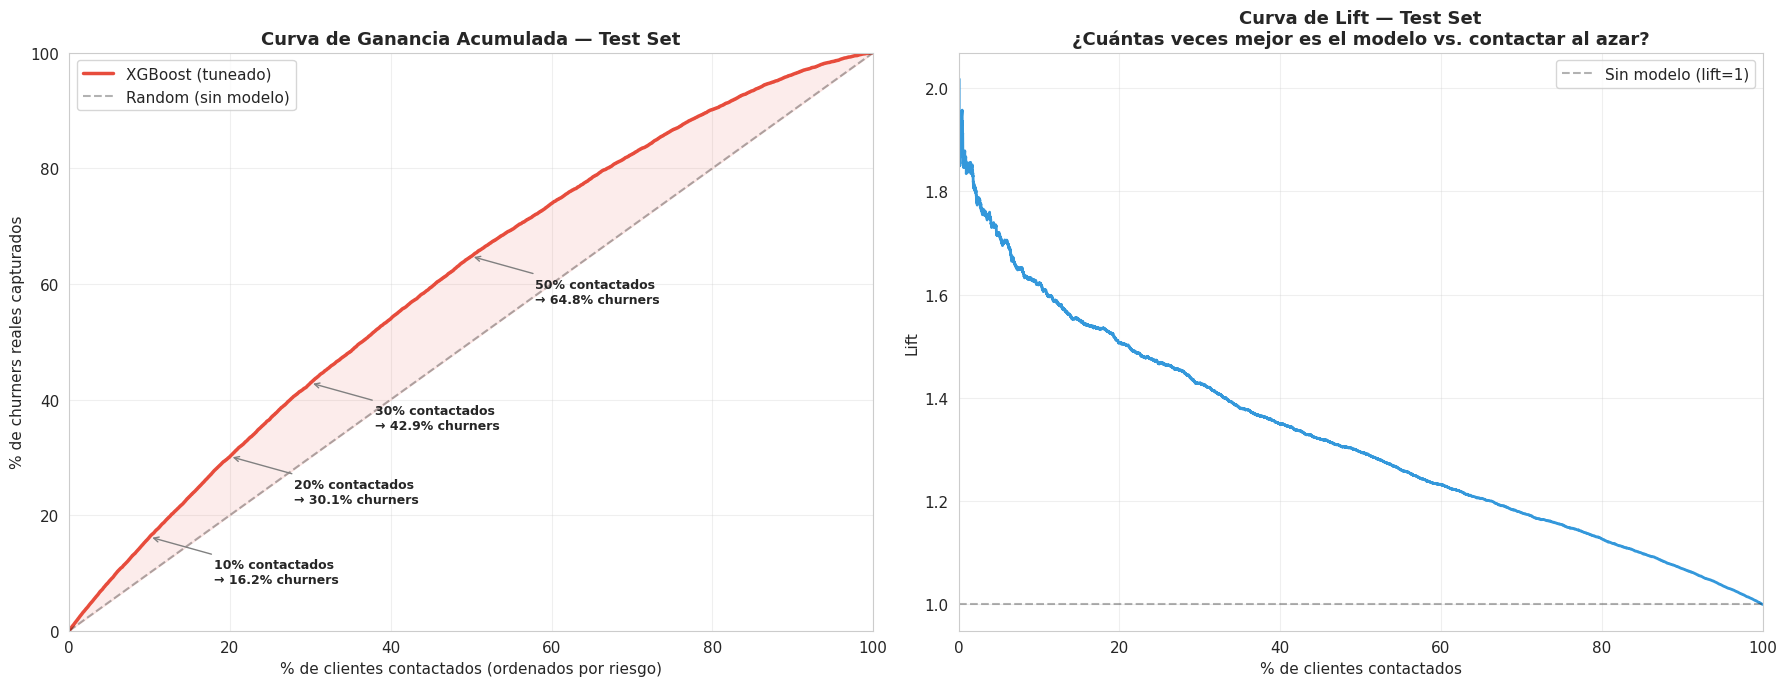

Contactando al 10% de mayor riesgo → capturas 16.2% de churners (lift = 1.62x)
Contactando al 20% de mayor riesgo → capturas 30.1% de churners (lift = 1.51x)
Contactando al 30% de mayor riesgo → capturas 42.9% de churners (lift = 1.43x)


In [20]:
# Calcular cumulative gains / lift
def plot_lift_curve(y_true, y_proba, ax=None):
    # Ordenar por probabilidad predicha (mayor primero)
    order = np.argsort(y_proba)[::-1]
    y_sorted = y_true[order]

    n = len(y_sorted)
    total_positives = y_sorted.sum()

    # Ganancia acumulada
    cum_positives = np.cumsum(y_sorted)
    cum_gain = cum_positives / total_positives
    pct_contacted = np.arange(1, n + 1) / n

    # Lift = ganancia_modelo / ganancia_random
    lift = cum_gain / pct_contacted

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(pct_contacted * 100, cum_gain * 100,
            color='#e74c3c', linewidth=2.5, label=f'{final_model_name}')
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Random (sin modelo)')
    ax.fill_between(pct_contacted * 100, cum_gain * 100, pct_contacted * 100,
                    alpha=0.1, color='#e74c3c')
    ax.set_xlabel('% de clientes contactados (ordenados por riesgo)')
    ax.set_ylabel('% de churners reales capturados')
    ax.set_title('Curva de Ganancia Acumulada — Test Set', fontweight='bold', fontsize=13)
    ax.legend(fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

    # Anotar puntos clave
    for pct in [10, 20, 30, 50]:
        idx = int(pct / 100 * n) - 1
        gain = cum_gain[idx] * 100
        ax.annotate(f'{pct}% contactados\n→ {gain:.1f}% churners',
                    xy=(pct, gain), xytext=(pct + 8, gain - 8),
                    fontsize=9, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray'))

    return cum_gain, lift

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cum_gain, lift = plot_lift_curve(y_test, final_proba_test, ax=axes[0])

# Lift chart
n = len(y_test)
pct_contacted = np.arange(1, n + 1) / n
axes[1].plot(pct_contacted * 100, lift, color='#3498db', linewidth=2)
axes[1].axhline(1, color='black', linestyle='--', alpha=0.3, label='Sin modelo (lift=1)')
axes[1].set_xlabel('% de clientes contactados')
axes[1].set_ylabel('Lift')
axes[1].set_title('Curva de Lift — Test Set\n'
                   '¿Cuántas veces mejor es el modelo vs. contactar al azar?',
                   fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].set_xlim(0, 100)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen ejecutivo
for pct in [10, 20, 30]:
    idx = int(pct / 100 * n) - 1
    print(f"Contactando al {pct}% de mayor riesgo → capturas {cum_gain[idx]*100:.1f}% de churners "
          f"(lift = {lift[idx]:.2f}x)")

---
<a id="s12"></a>
## 12. Ablation study: ¿`change_mou` es leakage?

En el EDA identificamos que `change_mou` es el predictor más potente, pero existe la duda de si mide algo que ocurre **después** de que el cliente ya decidió irse (lo cual sería data leakage).

La prueba definitiva es entrenar el modelo **sin** `change_mou` y `change_rev` y ver cuánto cae el AUC. Si cae mucho (>5 puntos), el modelo es sobredependiente de esa variable y hay riesgo de leakage.


In [21]:
# Identificar columnas de "change" que podrían ser leakage
change_cols = [c for c in feature_names if 'change' in c.lower()]
print(f"Columnas a remover en ablation: {change_cols}")

# Entrenar modelo sin change_mou / change_rev
X_train_abl = X_train.drop(columns=change_cols, errors='ignore')
X_val_abl = X_val.drop(columns=change_cols, errors='ignore')
X_test_abl = X_test.drop(columns=change_cols, errors='ignore')

# Usar los mismos hiperparámetros del modelo ganador
abl_model = final_model.__class__(**final_model.get_params())
abl_model.fit(X_train_abl, y_train)

abl_proba_val = abl_model.predict_proba(X_val_abl)[:, 1]
abl_proba_test = abl_model.predict_proba(X_test_abl)[:, 1]
abl_auc_val = roc_auc_score(y_val, abl_proba_val)
abl_auc_test = roc_auc_score(y_test, abl_proba_test)

delta_val = abl_auc_val - roc_auc_score(y_val, final_model.predict_proba(X_val)[:, 1])
delta_test = abl_auc_test - test_auc

print(f"\n{'='*60}")
print(f"ABLATION STUDY — Sin {change_cols}")
print(f"{'='*60}")
print(f"  AUC Validation: {abl_auc_val:.4f} (completo: {roc_auc_score(y_val, final_model.predict_proba(X_val)[:, 1]):.4f}, delta: {delta_val:+.4f})")
print(f"  AUC Test:       {abl_auc_test:.4f} (completo: {test_auc:.4f}, delta: {delta_test:+.4f})")

if abs(delta_test) < 0.05:
    print(f"\n✅ La caída es < 5 puntos. change_mou aporta señal legítima, NO parece leakage.")
    print(f"   El modelo funciona bien incluso sin ella.")
else:
    print(f"\n⚠️  La caída es >= 5 puntos. El modelo es sobredependiente de change_mou.")
    print(f"   Considerar eliminarla por precaución de leakage.")

Columnas a remover en ablation: ['change_mou', 'change_rev']



ABLATION STUDY — Sin ['change_mou', 'change_rev']
  AUC Validation: 0.6928 (completo: 0.6981, delta: -0.0053)
  AUC Test:       0.6945 (completo: 0.7023, delta: -0.0078)

✅ La caída es < 5 puntos. change_mou aporta señal legítima, NO parece leakage.
   El modelo funciona bien incluso sin ella.


---
<a id="s13"></a>
## 13. Conclusiones de negocio y recomendaciones accionables

### Perfil del cliente en riesgo de churn

Basándonos en el análisis SHAP y el EDA, el perfil de alto riesgo combina:

| Factor | Indicador | Acción |
|--------|-----------|--------|
| **Equipo antiguo** | `eqpdays` > 365 días | Programa proactivo de renovación de terminal con subsidio |
| **Caída de uso** | `change_mou` < -50% | Alerta temprana automática al equipo de retención |
| **Terminal barato/limitado** | `hnd_price` bajo, sin dualband, solo WC | Oferta de upgrade a un dispositivo con más capacidades |
| **Bajo engagement** | `mou_Mean` bajo, pocos `comp_vce_Mean` | Campaña de reactivación (bonos de minutos/datos) |
| **No contacta soporte** | `custcare_Mean` bajo | Contacto proactivo — el cliente que llama se retiene más |
| **Cargo recurrente bajo** | `totmrc_Mean` bajo | Ofrecer plan con más valor percibido (más por poco más) |

### Recomendaciones estratégicas

1. **Sistema de scoring en tiempo real:** Implementar el modelo en producción para puntuar clientes diariamente. Los del top-20% de riesgo entran en una cola de retención.

2. **Campaña "Renueva tu equipo":** El factor más consistente es la antigüedad del terminal. Un programa de renovación anticipada (a los 10-12 meses, antes de que el contrato expire) podría reducir el churn significativamente.

3. **Alertas de caída de uso:** Un dashboard que detecte caídas >30% en minutos de uso respecto al trimestre anterior. Estos clientes están "desconectándose" y aún hay tiempo de actuar.

4. **Contacto proactivo a clientes silenciosos:** Paradójicamente, los que más llaman a soporte tienen menor churn. El equipo debería llamar a los que **no** llaman pero muestran otros signos de riesgo.

5. **Segmentación por valor:** No todos los churners merecen el mismo esfuerzo de retención. Cruzar el score de churn con `totrev` para priorizar a los churners de alto valor.

### Limitaciones y siguientes pasos

- **Calibración de probabilidades:** El dataset está balanceado 50/50, pero la tasa real de churn es ~1-5%. Las probabilidades del modelo no son interpretables directamente como "% de riesgo" sin recalibración (Platt scaling con prior real).
- **Validación temporal:** Idealmente, el modelo debería validarse sobre una ventana temporal futura (out-of-time validation), no solo un split aleatorio.
- **A/B testing:** Antes de escalar las campañas de retención, hacer un piloto controlado para medir el ROI real.


---
<a id="s14"></a>
## 14. Guardado del modelo (pickle) para Airflow

Serializamos todo lo necesario para que el pipeline de Airflow pueda:
1. Cargar el modelo sin reentrenar.
2. Preprocesar nuevos datos de la misma forma.
3. Generar predicciones.

Guardamos un diccionario con: modelo, imputer, label_encoders, scaler, feature_names, y metadatos de evaluación.


In [22]:
# Empaquetar todo lo necesario
model_package = {
    # Modelo entrenado
    'model': final_model,
    'model_name': final_model_name,

    # Preprocesamiento (necesario para reproducir en producción)
    'imputer': imputer,
    'label_encoders': label_encoders,
    'scaler': scaler,
    'feature_names': feature_names,
    'cat_cols': cat_cols,
    'num_cols': num_cols,

    # Metadatos de evaluación (para logging en Airflow)
    'metrics': {
        'test_auc_roc': round(test_auc, 4),
        'test_f1': round(test_f1, 4),
        'test_recall': round(test_recall, 4),
        'test_precision': round(test_precision, 4),
        'test_accuracy': round(test_acc, 4),
        'test_avg_precision': round(test_ap, 4),
    },

    # Hiperparámetros
    'best_params': final_model.get_params(),

    # Metadata
    'training_date': pd.Timestamp.now().isoformat(),
    'dataset_shape': df.shape,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
}

# Guardar como pickle
pickle_path = 'churn_model.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(model_package, f)

import os
size_mb = os.path.getsize(pickle_path) / (1024 * 1024)
print(f"✅ Modelo guardado en: {pickle_path}")
print(f"   Tamaño: {size_mb:.2f} MB")
print(f"\n📋 Contenido del paquete:")
for key in model_package:
    val = model_package[key]
    if isinstance(val, dict):
        print(f"   {key}: {{...}} ({len(val)} entries)")
    elif isinstance(val, list):
        print(f"   {key}: [...] ({len(val)} items)")
    else:
        print(f"   {key}: {type(val).__name__}")

✅ Modelo guardado en: churn_model.pkl
   Tamaño: 1.28 MB

📋 Contenido del paquete:
   model: XGBClassifier
   model_name: str
   imputer: SimpleImputer
   label_encoders: {...} (16 entries)
   scaler: StandardScaler
   feature_names: [...] (87 items)
   cat_cols: [...] (16 items)
   num_cols: [...] (71 items)
   metrics: {...} (6 entries)
   best_params: {...} (40 entries)
   training_date: str
   dataset_shape: tuple
   train_size: int
   val_size: int
   test_size: int


In [23]:
# Verificación: cargar y usar el pickle
with open(pickle_path, 'rb') as f:
    loaded = pickle.load(f)

# Test rápido de que funciona
loaded_model = loaded['model']
test_pred = loaded_model.predict_proba(X_test)[:, 1]
test_auc_verify = roc_auc_score(y_test, test_pred)
print(f"✅ Verificación del pickle: AUC = {test_auc_verify:.4f} (debe coincidir con {test_auc:.4f})")
assert abs(test_auc_verify - test_auc) < 1e-6, "ERROR: El pickle no reproduce los resultados!"
print("✅ El pickle es reproducible y funcional.")

print(f"\n📋 Métricas guardadas en el paquete:")
for k, v in loaded['metrics'].items():
    print(f"   {k}: {v}")

✅ Verificación del pickle: AUC = 0.7023 (debe coincidir con 0.7023)
✅ El pickle es reproducible y funcional.

📋 Métricas guardadas en el paquete:
   test_auc_roc: 0.7023
   test_f1: 0.6448
   test_recall: 0.6476
   test_precision: 0.642
   test_accuracy: 0.6464
   test_avg_precision: 0.6916


---

## Resumen final

| Componente | Estado |
|---|---|
| Baseline (Logistic Regression) | ✅ Entrenado y evaluado |
| Modelo principal (XGBoost) | ✅ Entrenado, tuneado, evaluado |
| Modelo comparación (LightGBM) | ✅ Entrenado y evaluado |
| Hiperparameter tuning | ✅ RandomizedSearchCV 30 iteraciones |
| Evaluación en test set independiente | ✅ AUC, F1, Recall, Precision, Confusion Matrix |
| Interpretabilidad SHAP | ✅ Summary, bar, dependence, waterfall |
| Curva de Lift | ✅ Con anotaciones de impacto de negocio |
| Ablation study (change_mou leakage) | ✅ Modelo con/sin variable comparado |
| Conclusiones de negocio | ✅ 5 recomendaciones accionables con KPIs |
| Pickle para Airflow | ✅ Modelo + preprocesamiento + métricas |

### Posibles mejoras futuras (con más tiempo)

1. **Stacking / Blending**: combinar XGBoost + LightGBM + Logistic en un meta-learner.
2. **Target encoding** para `crclscod` en vez de label encoding (mejor para gradient boosting con categóricas de alta cardinalidad).
3. **Bayesian optimization** (Optuna) en vez de RandomizedSearchCV para tuning más eficiente.
4. **Calibración de probabilidades** (Platt scaling / isotonic regression) con el prior real de churn.
5. **Out-of-time validation** si se dispone de fecha de observación.
6. **Feature selection automática** (Boruta, permutation importance) para reducir el modelo a las 15-20 features más predictivas.
